In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer
from datasets import Dataset

In [29]:
df = pd.read_csv('tracks_with_lyrics.csv', encoding='utf-8-sig')

In [30]:
model_name = "roberta-base"
model = AutoModelForSequenceClassification.from_pretrained("roberta")
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [31]:
def tokenize_function(examples):
    return tokenizer(examples["lyrics"], padding="max_length", truncation=True, max_length=512)

In [32]:
test_dataset = Dataset.from_pandas(df)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/7219 [00:00<?, ? examples/s]

In [33]:
trainer = Trainer(model=model, tokenizer=tokenizer)
preds = trainer.predict(test_dataset)

<ipython-input-33-201f48d7a635>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


In [34]:
y_pred = np.argmax(preds.predictions, axis = 1)
id2label = {0: 'fear', 1: 'sadness', 2: 'anger', 3: 'disgust', 4: 'joy', 5: 'surprise'}

df['label'] = y_pred
df["label_name"] = [id2label[i] for i in y_pred]


In [35]:
df.to_csv('tracks_with_lyrics_and_labels.csv', index=False)

In [36]:
df = pd.read_csv('tracks_with_lyrics_and_labels.csv', encoding='utf-8-sig')

In [37]:
display(df.head())
print(df.info())
print(df['popularity'].describe())
print("Benzersiz duygular:", df['label_name'].nunique())


,track_id,title,artist,genre,release_year,popularity,lyrics,label,label_name
0,2lKNANmq1EjeXcTyY01tGq,Bad Habits,Ed Sheeran,pop,2023,17,"(One, two, three, four)\nOoh, ooh\nEvery time ...",1,sadness
1,1OIyqRCSCSsTpORSVcSbJH,Light Switch,Charlie Puth,pop,2023,13,Yeah\nWhy you callin' at 11:30\nWhen you only ...,0,fear
2,7973tPp6ZA4q1AAEoLLMqE,Iris,The Goo Goo Dolls,pop,2023,11,And I'd give up forever to touch you\n'Cause I...,1,sadness
3,5fYNlXNcNp8BzgezT733jo,Overwhelmed,Royal & the Serpent,pop,2023,3,"To report suspicious activity, you can call 91...",0,fear
4,4xeRHrHTOij2Ux6aHRlq0O,Infinity,Jaymes Young,pop,2023,11,"(Oh, oh)\n(Oh, oh, oh)\n(Oh, oh)\n(Oh, oh, oh)...",2,anger


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7219 entries, 0 to 7218
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   track_id      7219 non-null   object
 1   title         7219 non-null   object
 2   artist        7219 non-null   object
 3   genre         7219 non-null   object
 4   release_year  7219 non-null   int64 
 5   popularity    7219 non-null   int64 
 6   lyrics        7219 non-null   object
 7   label         7219 non-null   int64 
 8   label_name    7219 non-null   object
dtypes: int64(3), object(6)
memory usage: 507.7+ KB
None
count    7219.000000
mean       56.243801
std        22.487529
min         0.000000
25%        48.000000
50%        61.000000
75%        71.000000
max        98.000000
Name: popularity, dtype: float64
Benzersiz duygular: 6


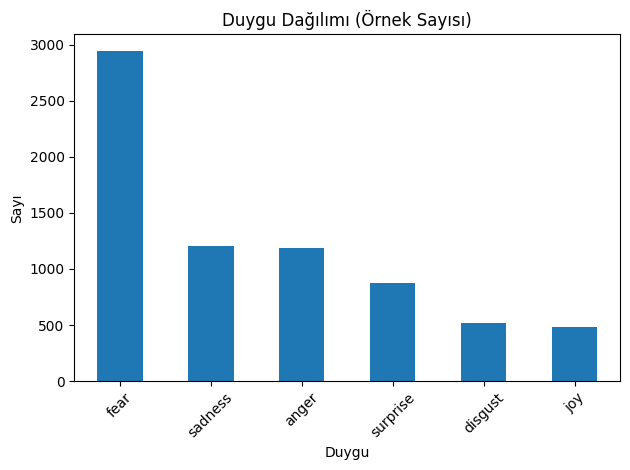

In [38]:
counts = df['label_name'].value_counts()
plt.figure()
counts.plot.bar()
plt.title('Duygu Dağılımı (Örnek Sayısı)')
plt.xlabel('Duygu')
plt.ylabel('Sayı')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

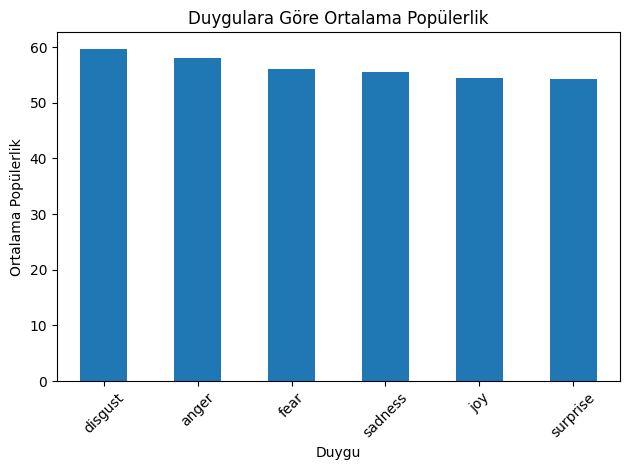

In [39]:
# ## 4. Duygulara Göre Ortalama Popülerlik

mean_pop_by_emotion = df.groupby('label_name')['popularity'].mean().sort_values(ascending=False)
plt.figure()
mean_pop_by_emotion.plot.bar()
plt.title('Duygulara Göre Ortalama Popülerlik')
plt.xlabel('Duygu')
plt.ylabel('Ortalama Popülerlik')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

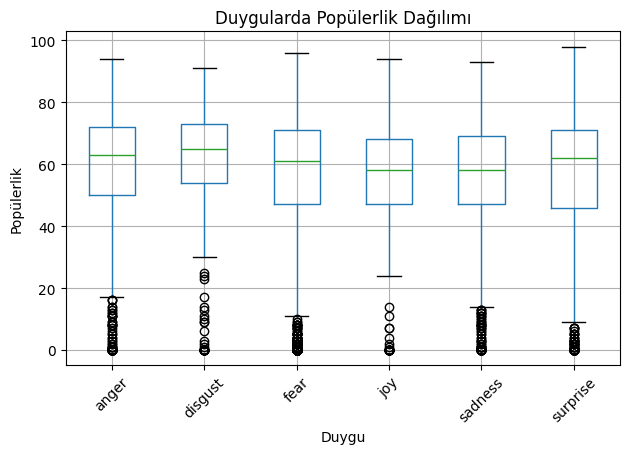

In [40]:
# ## 5. Duygularda Popülerlik Dağılımı

plt.figure()
df.boxplot(column='popularity', by='label_name', rot=45)
plt.title('Duygularda Popülerlik Dağılımı')
plt.suptitle('')
plt.xlabel('Duygu')
plt.ylabel('Popülerlik')
plt.tight_layout()
plt.show()

label_name,anger,disgust,fear,joy,sadness,surprise
genre,,,,,,
blues,269,138,616,96,226,183
country,222,112,567,89,246,157
hip-hop,266,105,536,99,206,141
pop,220,82,645,111,277,202
r&b,23,13,53,9,27,14
rock,188,69,527,78,227,180


<Figure size 640x480 with 0 Axes>

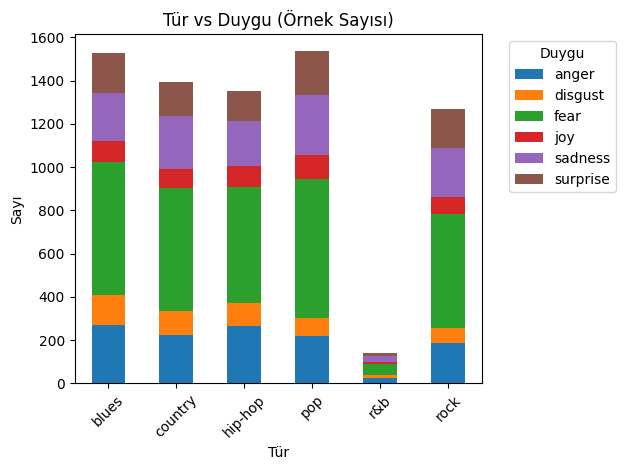

In [41]:
# ## 6. Tür vs Duygu – Örnek Sayıları

ct = pd.crosstab(df['genre'], df['label_name'])
display(ct)

plt.figure()
ct.plot.bar(stacked=True)
plt.title('Tür vs Duygu (Örnek Sayısı)')
plt.xlabel('Tür')
plt.ylabel('Sayı')
plt.xticks(rotation=45)
plt.legend(title='Duygu', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

label_name,anger,disgust,fear,joy,sadness,surprise
genre,,,,,,
blues,67.739777,68.137681,67.668831,67.072917,65.778761,67.387978
country,61.234234,63.392857,59.425044,58.730337,56.471545,60.114650
hip-hop,51.259398,48.342857,59.277985,56.828283,58.995146,56.134752
pop,50.186364,51.658537,46.272868,41.954955,48.772563,50.509901
r&b,74.086957,72.307692,71.830189,71.111111,67.518519,73.285714
rock,57.223404,61.130435,46.273245,46.589744,48.079295,36.733333


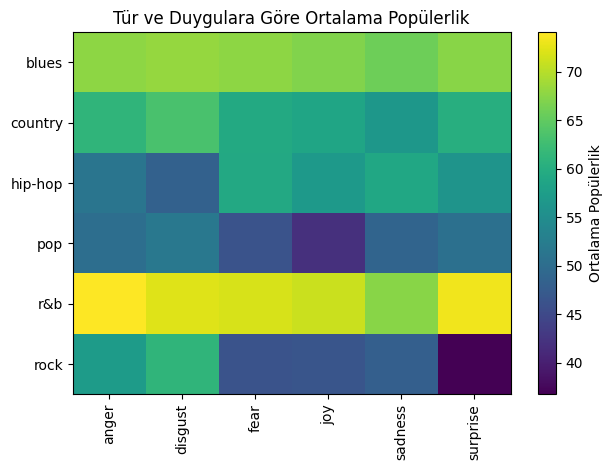

In [42]:
# ## 7. Tür ve Duygulara Göre Ortalama Popülerlik
pivot_mean = df.pivot_table(
    index='genre',
    columns='label_name',
    values='popularity',
    aggfunc='mean'
).fillna(0)
display(pivot_mean)

plt.figure()
plt.imshow(pivot_mean.values, aspect='auto')
plt.xticks(range(pivot_mean.shape[1]), pivot_mean.columns, rotation=90)
plt.yticks(range(pivot_mean.shape[0]), pivot_mean.index)
plt.title('Tür ve Duygulara Göre Ortalama Popülerlik')
plt.colorbar(label='Ortalama Popülerlik')
plt.tight_layout()
plt.show()


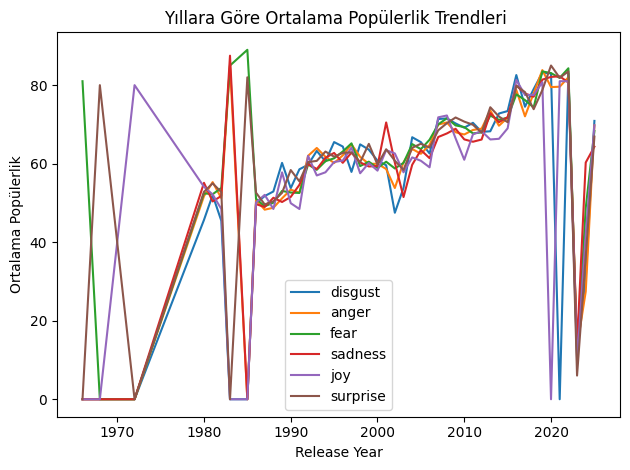

In [43]:
# ## 8. Zaman İçinde Duygu Popülerlik Trendleri

yearly = df.groupby(['release_year', 'label_name'])['popularity'].mean().unstack().fillna(0)

top_emotions = mean_pop_by_emotion.index
plt.figure()
for emo in top_emotions:
    plt.plot(yearly.index, yearly[emo], label=emo)
plt.title('Yıllara Göre Ortalama Popülerlik Trendleri ')
plt.xlabel('Release Year')
plt.ylabel('Ortalama Popülerlik')
plt.legend()
plt.tight_layout()
plt.show()
